In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Set the Data paths
bin_data_path = r'C:\Users\rdbra\Documents\honoursProject\code_base\Hon_proj_RDB\GRN_work\data\sct_top5k_bin.npz'
ce_recon_path = r'C:\Users\rdbra\Documents\honoursProject\code_base\Hon_proj_RDB\GRN_work\vqvae2_results\sct_top5k_1000_7_vqvae2_1762730894\vqvae2_recon.npz'
focal_recon_path = r'C:\Users\rdbra\Documents\honoursProject\code_base\Hon_proj_RDB\GRN_work\vqvae2_results\sct_top5k_1000_7_vqvae2_focal_1763325705\vqvae2_recon.npz'
wce_recon_path = r'C:\Users\rdbra\Documents\honoursProject\code_base\Hon_proj_RDB\GRN_work\vqvae2_results\sct_top5k_1000_7_vqvae2_wce_1763300537\vqvae2_recon.npz'

# Binned Data Loading and reconstruction loading

In [38]:
bin_data = np.load(bin_data_path, allow_pickle=True)
ce_recon = np.load(ce_recon_path, allow_pickle=True)
focal_recon = np.load(focal_recon_path, allow_pickle=True)
wce_recon = np.load(wce_recon_path, allow_pickle=True)
print('bin_data keys:', bin_data.files)
print('ce_recon keys:', ce_recon.files)
print('focal_recon keys:', focal_recon.files)
print('wce_recon keys:', wce_recon.files)
bin_exp = bin_data['data']
ce_exp_recon = ce_recon['reconstructed_matrix']
focal_exp_recon = focal_recon['reconstructed_matrix']
wce_exp_recon = wce_recon['reconstructed_matrix']
#print the max value in each ofh te matrices
print('Max value in bin_exp:', np.max(bin_exp))
print('Max value in ce_exp_recon:', np.max(ce_exp_recon))
print('Max value in focal_exp_recon:', np.max(focal_exp_recon))
print('Max value in wce_exp_recon:', np.max(wce_exp_recon))

bin_data keys: ['data', 'genes', 'cells']
ce_recon keys: ['reconstructed_matrix']
focal_recon keys: ['reconstructed_matrix']
wce_recon keys: ['reconstructed_matrix']
Max value in bin_exp: 7.0
Max value in ce_exp_recon: 3.0
Max value in focal_exp_recon: 7.0
Max value in wce_exp_recon: 3.0


# Data Sparsity Analysis

Binned Expression Data Sparsity: 0.8290
CE VQ-VAE Reconstruction Sparsity: 0.9465
Focal VQ-VAE Reconstruction Sparsity: 0.6139
WCE VQ-VAE Reconstruction Sparsity: 0.9517


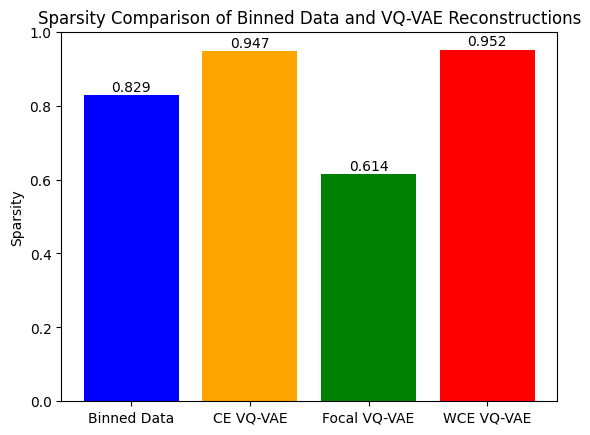

In [31]:
def compute_sparsity(matrix):
    total_elements = matrix.size
    non_zero_elements = np.count_nonzero(matrix)
    sparsity = 1 - (non_zero_elements / total_elements)
    return sparsity
bin_exp_sparsity = compute_sparsity(bin_exp)
focal_recon_sparsity = compute_sparsity(focal_exp_recon)
wce_recon_sparsity = compute_sparsity(wce_exp_recon)   
ce_recon_sparsity = compute_sparsity(ce_exp_recon)
print(f'Binned Expression Data Sparsity: {bin_exp_sparsity:.4f}')
print(f'CE VQ-VAE Reconstruction Sparsity: {ce_recon_sparsity:.4f}')
print(f'Focal VQ-VAE Reconstruction Sparsity: {focal_recon_sparsity:.4f}')
print(f'WCE VQ-VAE Reconstruction Sparsity: {wce_recon_sparsity:.4f}')


# Plot the sparsity comparison
labels = ['Binned Data','CE VQ-VAE', 'Focal VQ-VAE', 'WCE VQ-VAE']
sparsity_values = [bin_exp_sparsity, ce_recon_sparsity, focal_recon_sparsity, wce_recon_sparsity]
# Label each bar with its sparsity value   
for i, v in enumerate(sparsity_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=10)
plt.bar(labels, sparsity_values, color=['blue', 'orange', 'green', 'red'])
plt.ylabel('Sparsity') 
plt.title('Sparsity Comparison of Binned Data and VQ-VAE Reconstructions')
plt.ylim(0, 1)
plt.show()

# Reconstruction Quality
## Binary Accuracy

In [18]:
def calculate_binary_accuracy(original, reconstructed):
    # Calculate the number of zeros assigned correctly
    correct_zeros = np.sum((reconstructed == original) & (original == 0))
    true_zeros = np.sum(original == 0)
    correct_non_zeros = np.sum((original == reconstructed) & (original != 0))
    true_non_zeros = np.sum(original != 0)
    total_elements = original.size 
    bin_accuracy = (correct_zeros + correct_non_zeros) / total_elements
    zero_accuracy = correct_zeros / true_zeros if true_zeros > 0 else 0
    non_zero_accuracy = correct_non_zeros / true_non_zeros if true_non_zeros > 0 else 0
    return bin_accuracy, zero_accuracy, non_zero_accuracy

def computer_per_bin_accuracy(original, reconstructed):
    per_bin_accuracies = []
    unique_bins = np.unique(original)
    num_bins = len(unique_bins)
    for bin_idx in range(num_bins):
        correct = np.sum((original == reconstructed) & (original == bin_idx))
        total = np.sum(original == bin_idx)
        accuracy = correct / total if total > 0 else 0
        per_bin_accuracies.append(accuracy)
    return per_bin_accuracies

focal_accuracy = calculate_binary_accuracy(bin_exp, focal_exp_recon)
wce_accuracy = calculate_binary_accuracy(bin_exp, wce_exp_recon)   

focal_per_bin_acc = computer_per_bin_accuracy(bin_exp, focal_exp_recon)
wce_per_bin_acc = computer_per_bin_accuracy(bin_exp, wce_exp_recon)
num_bins = 8
print(f'Focal VQ-VAE2 Binary Accuracy: {focal_accuracy[0]*100:.2f}%, Zero Accuracy: {focal_accuracy[1]*100:.2f}%, Non-Zero Accuracy: {focal_accuracy[2]*100:.2f}%')
for bin_idx in range(num_bins):
    print(f'    Focal VQ-VAE2 Bin {bin_idx} Accuracy: {focal_per_bin_acc[bin_idx]*100:.2f}%')
print(f'WCE VQ-VAE2 Binary Accuracy: {wce_accuracy[0]*100:.2f}%, Zero Accuracy: {wce_accuracy[1]*100:.2f}%, Non-Zero Accuracy: {wce_accuracy[2]*100:.2f}%')
for bin_idx in range(num_bins):
    print(f'    WCE VQ-VAE2 Bin {bin_idx} Accuracy: {wce_per_bin_acc[bin_idx]*100:.2f}%')

Focal VQ-VAE2 Binary Accuracy: 67.19%, Zero Accuracy: 68.93%, Non-Zero Accuracy: 58.74%
    Focal VQ-VAE2 Bin 0 Accuracy: 68.93%
    Focal VQ-VAE2 Bin 1 Accuracy: 58.22%
    Focal VQ-VAE2 Bin 2 Accuracy: 60.23%
    Focal VQ-VAE2 Bin 3 Accuracy: 69.28%
    Focal VQ-VAE2 Bin 4 Accuracy: 57.83%
    Focal VQ-VAE2 Bin 5 Accuracy: 93.75%
    Focal VQ-VAE2 Bin 6 Accuracy: 96.26%
    Focal VQ-VAE2 Bin 7 Accuracy: 97.32%
WCE VQ-VAE2 Binary Accuracy: 84.53%, Zero Accuracy: 98.65%, Non-Zero Accuracy: 16.10%
    WCE VQ-VAE2 Bin 0 Accuracy: 98.65%
    WCE VQ-VAE2 Bin 1 Accuracy: 13.90%
    WCE VQ-VAE2 Bin 2 Accuracy: 35.42%
    WCE VQ-VAE2 Bin 3 Accuracy: 30.25%
    WCE VQ-VAE2 Bin 4 Accuracy: 0.00%
    WCE VQ-VAE2 Bin 5 Accuracy: 0.00%
    WCE VQ-VAE2 Bin 6 Accuracy: 0.00%
    WCE VQ-VAE2 Bin 7 Accuracy: 0.00%


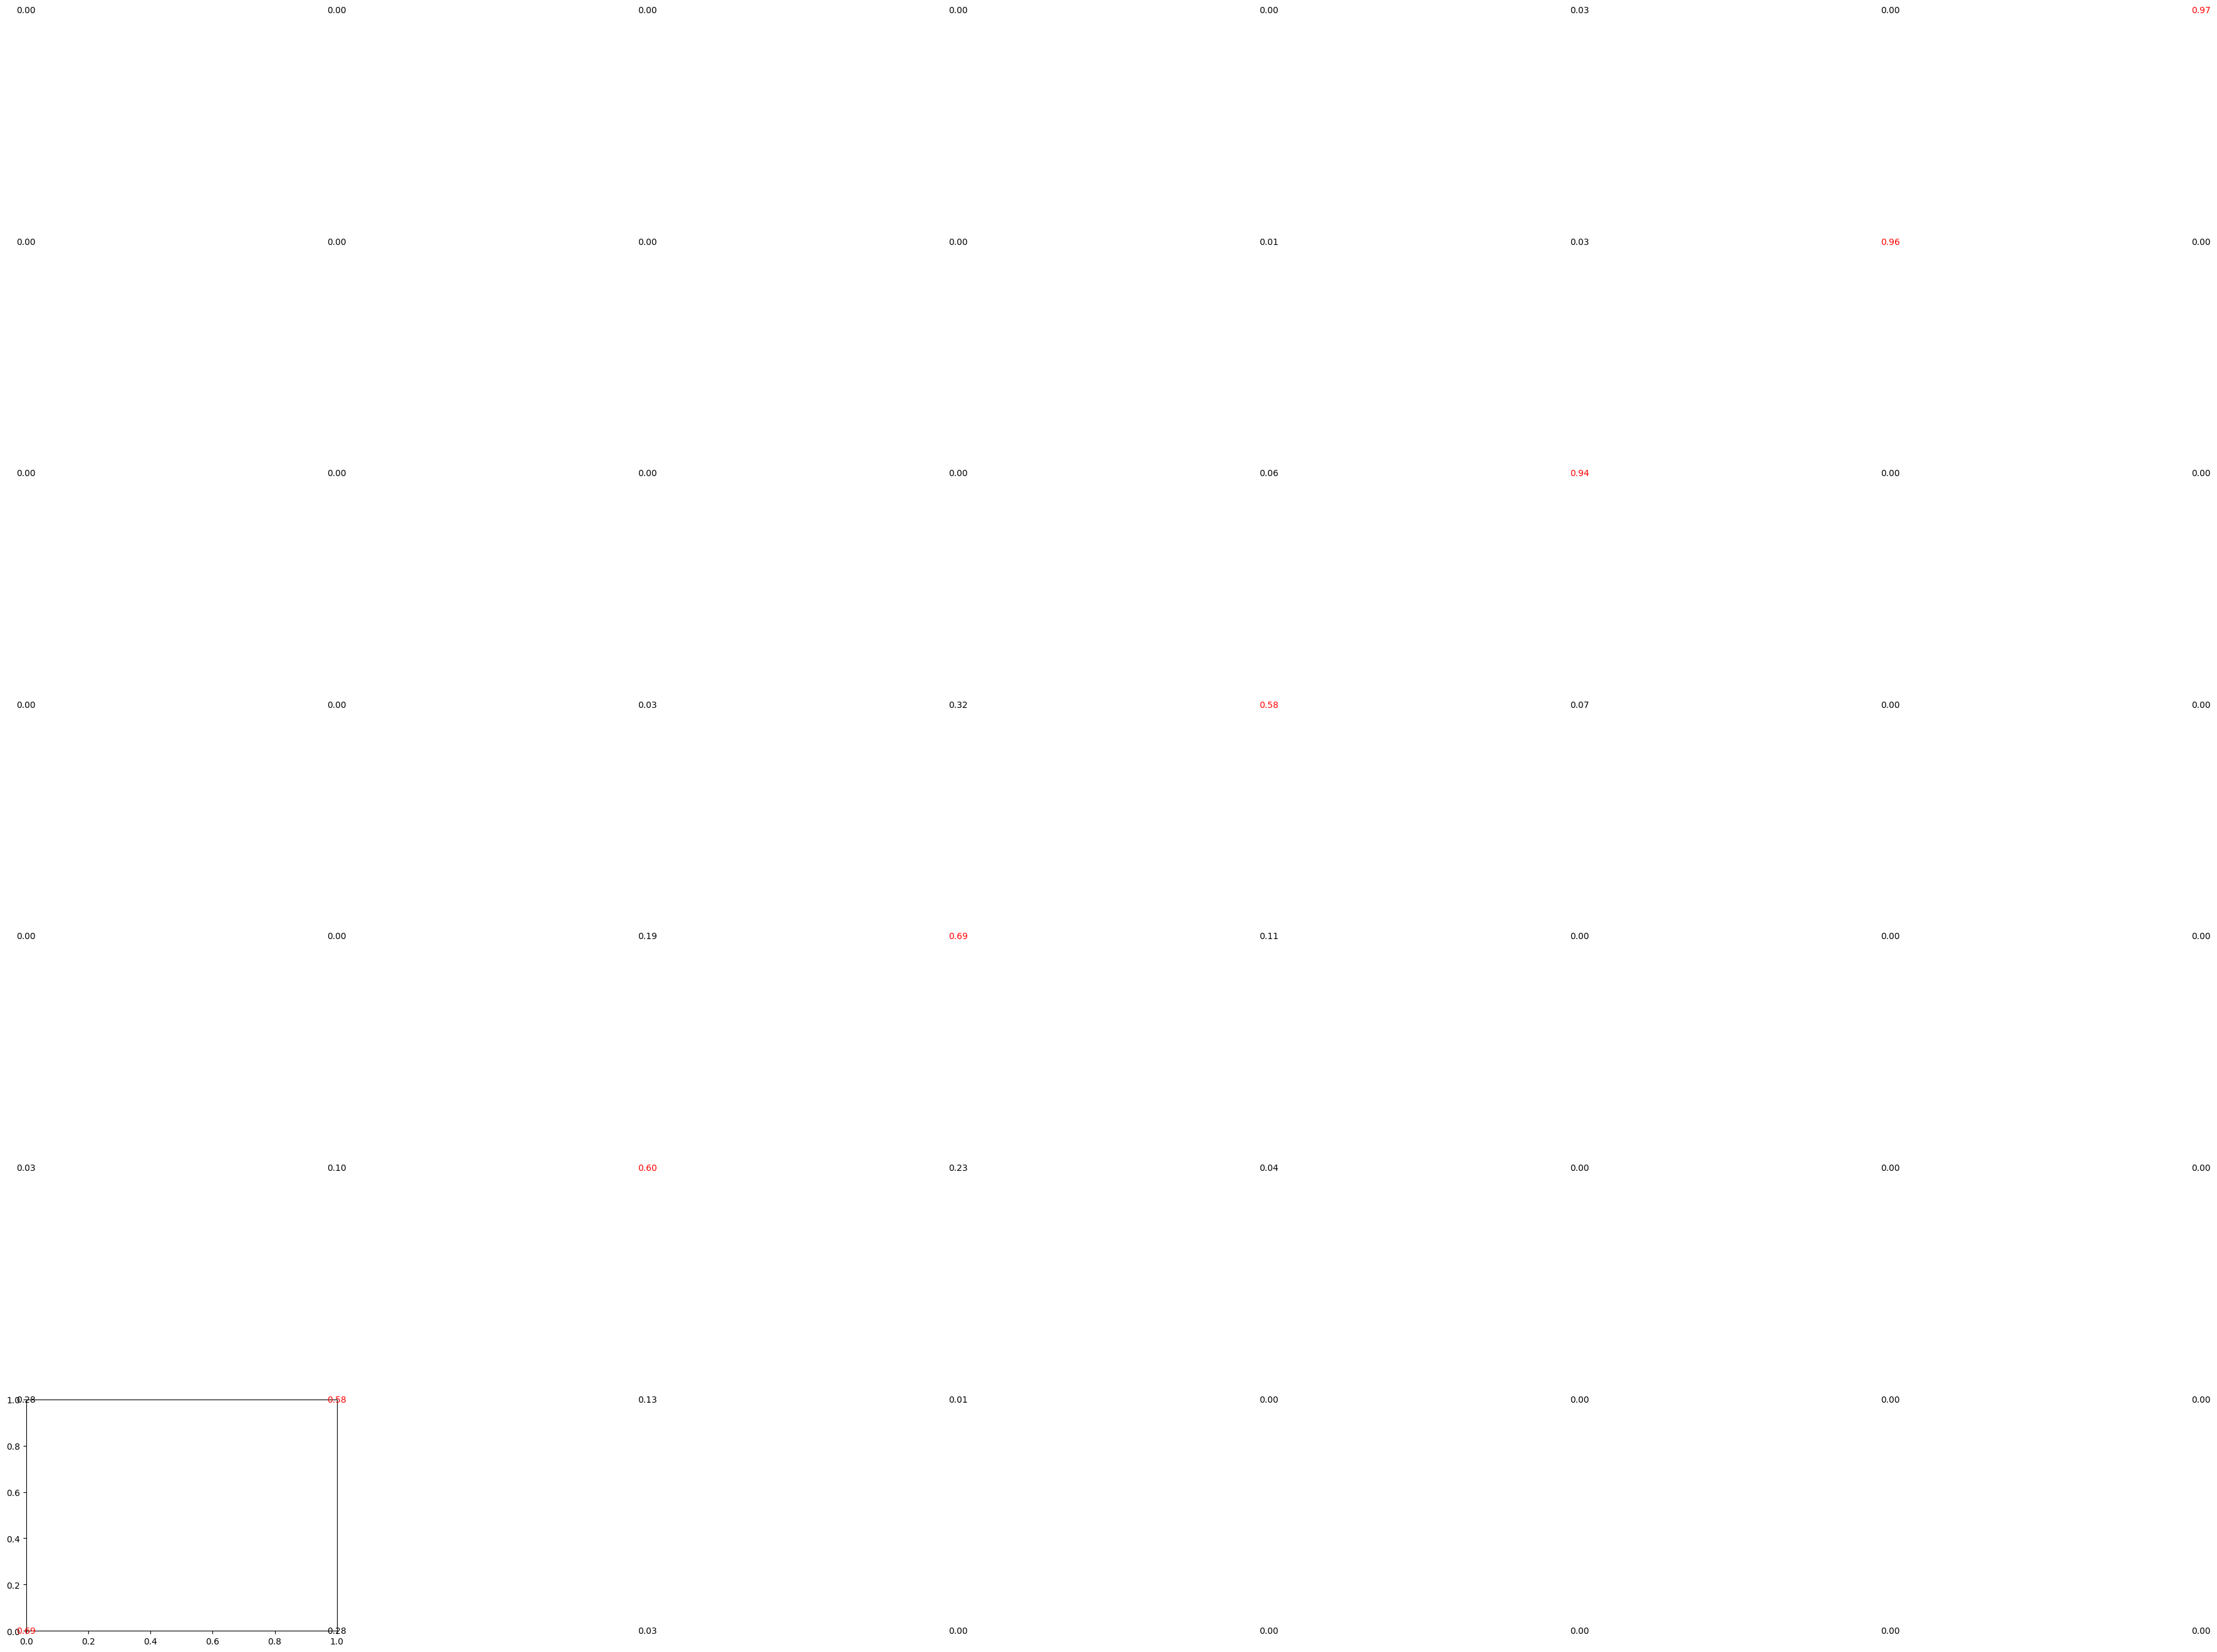

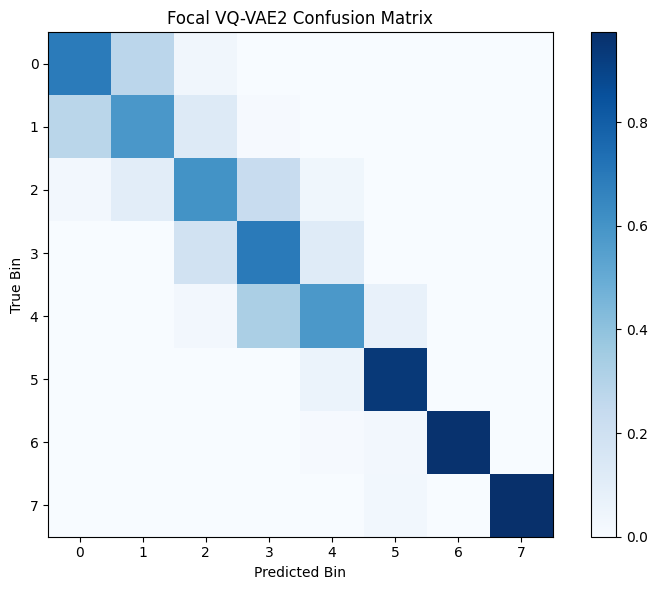

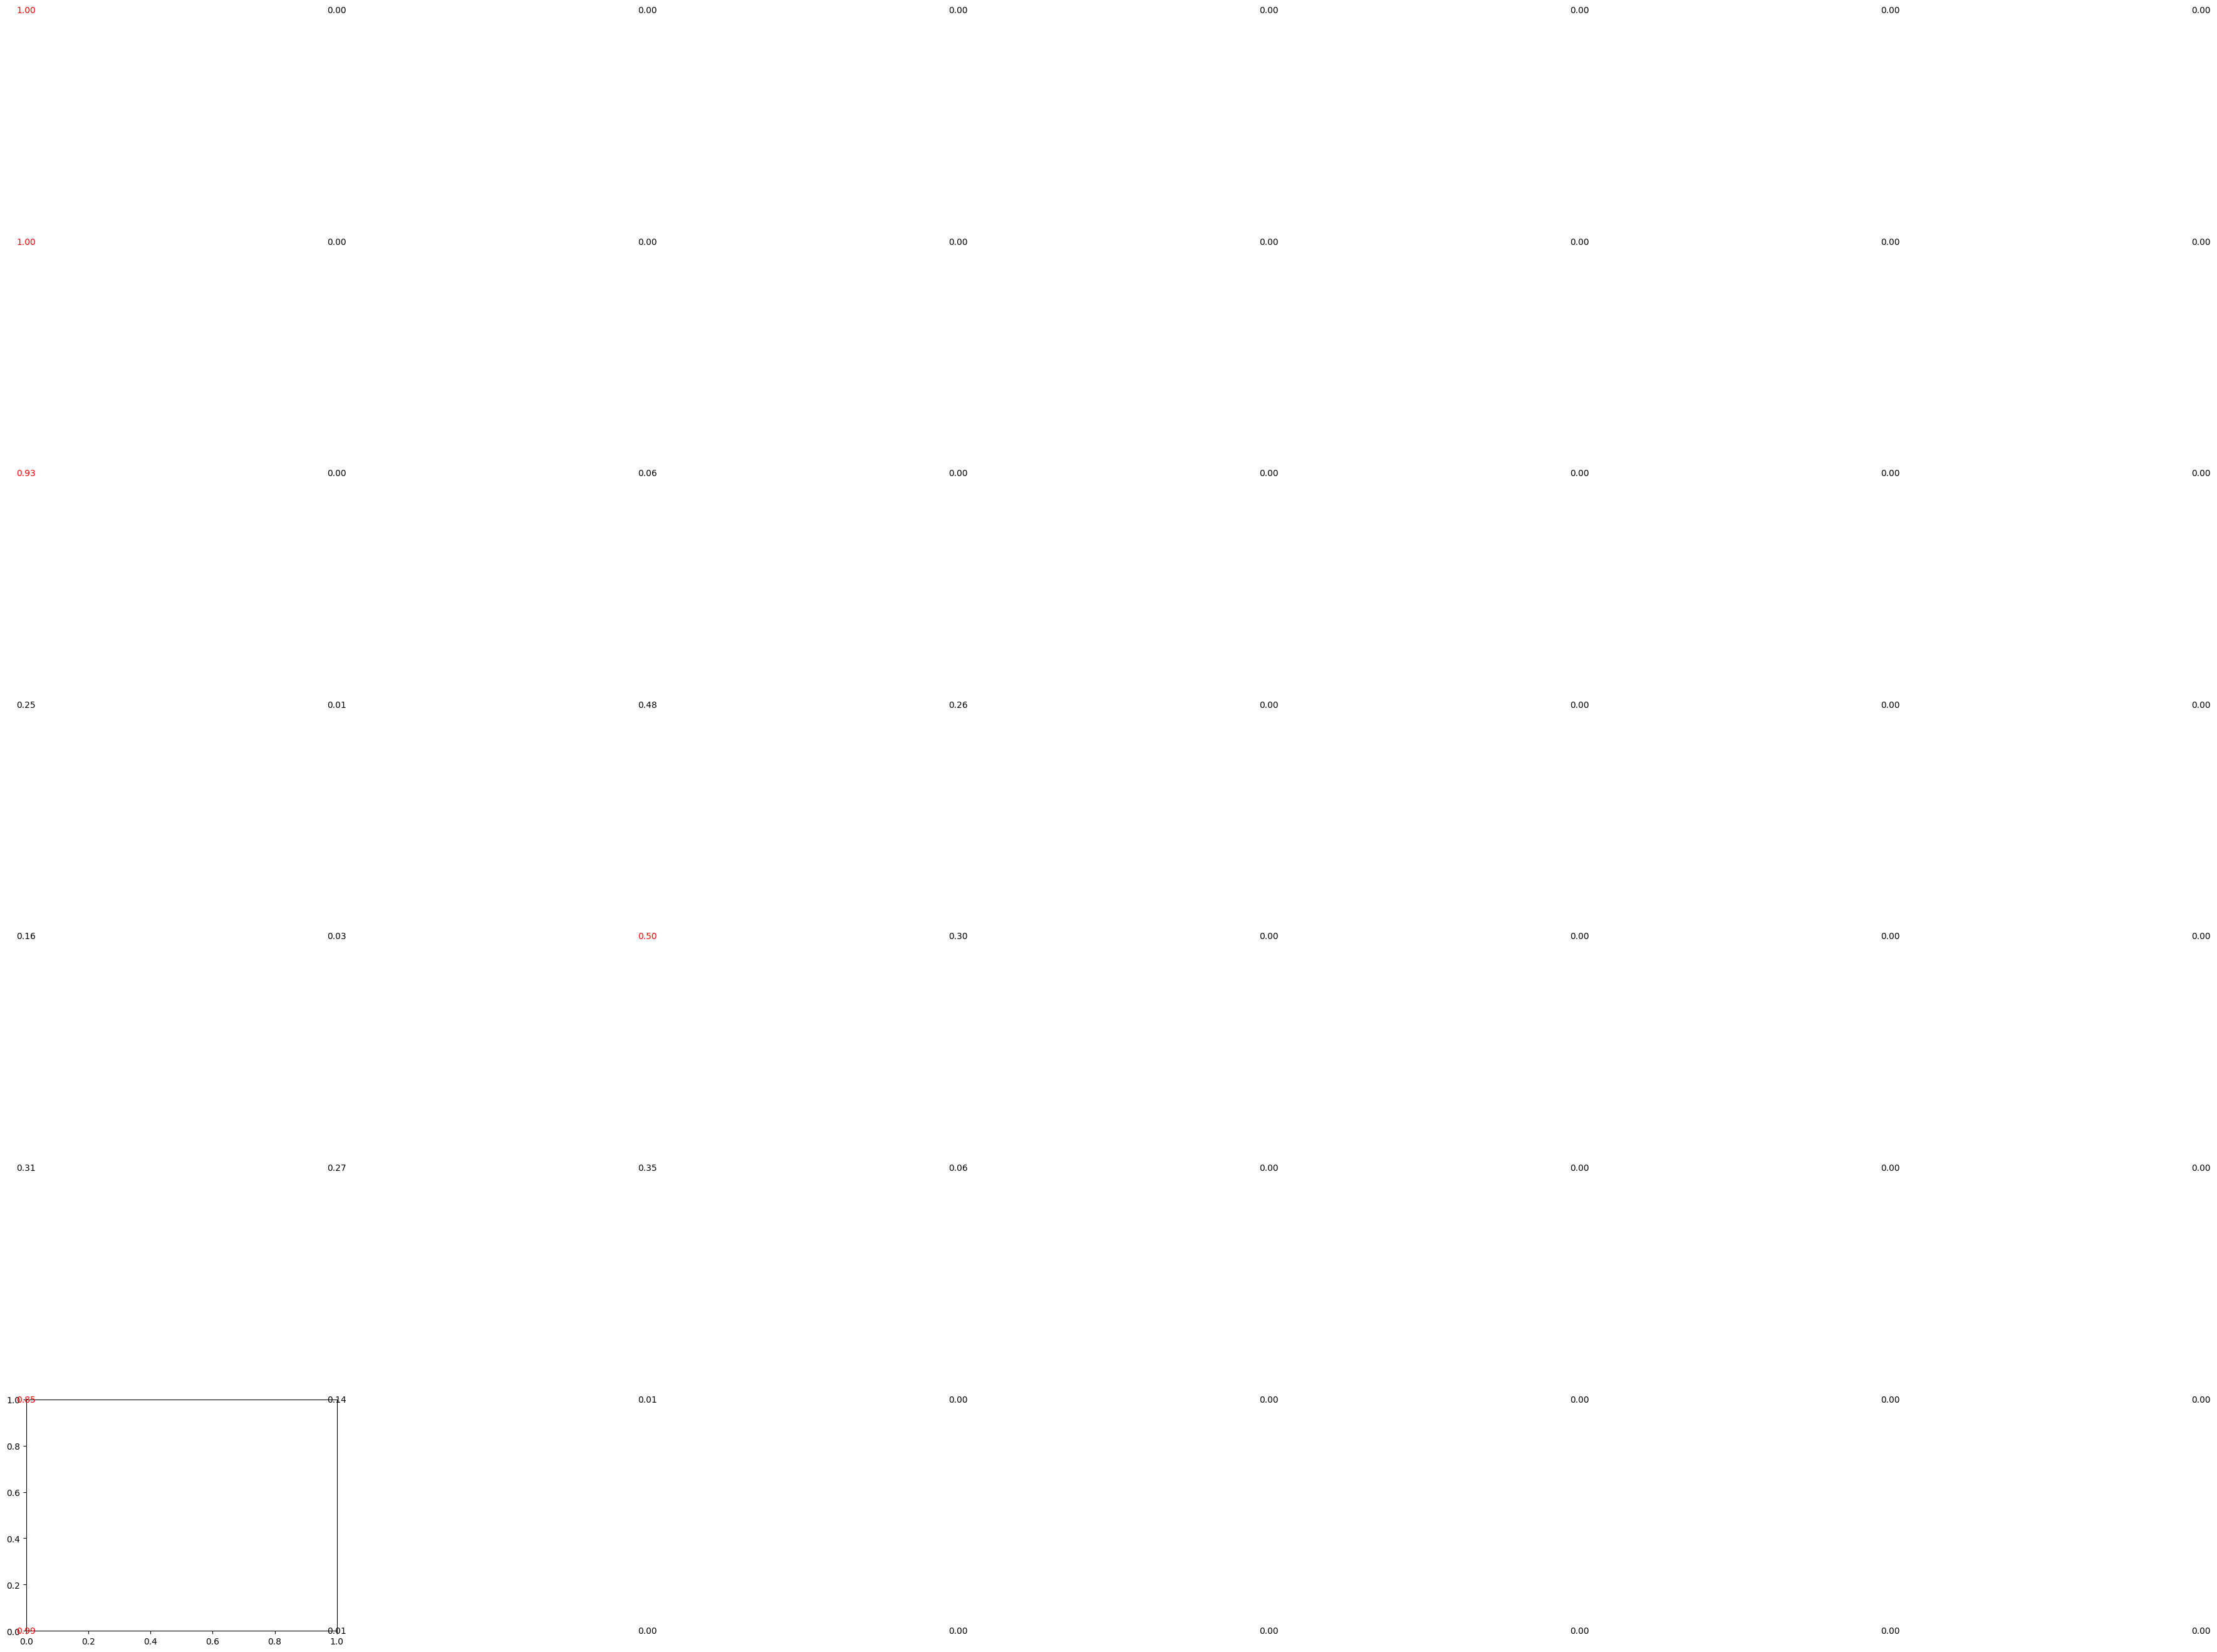

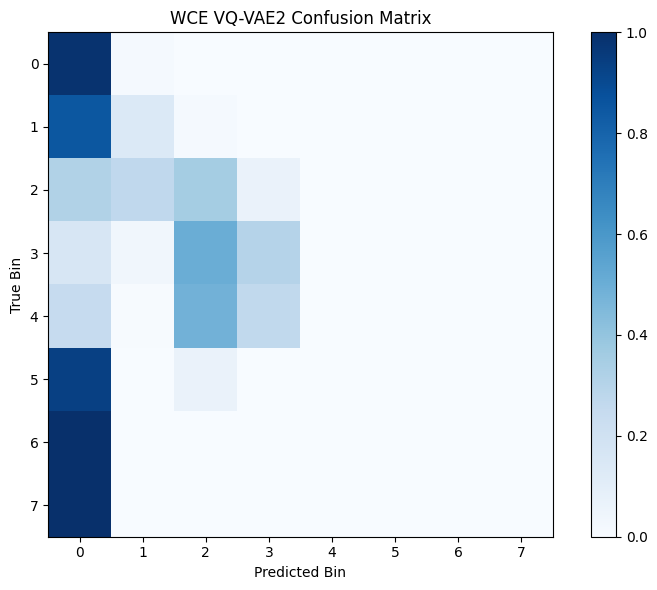

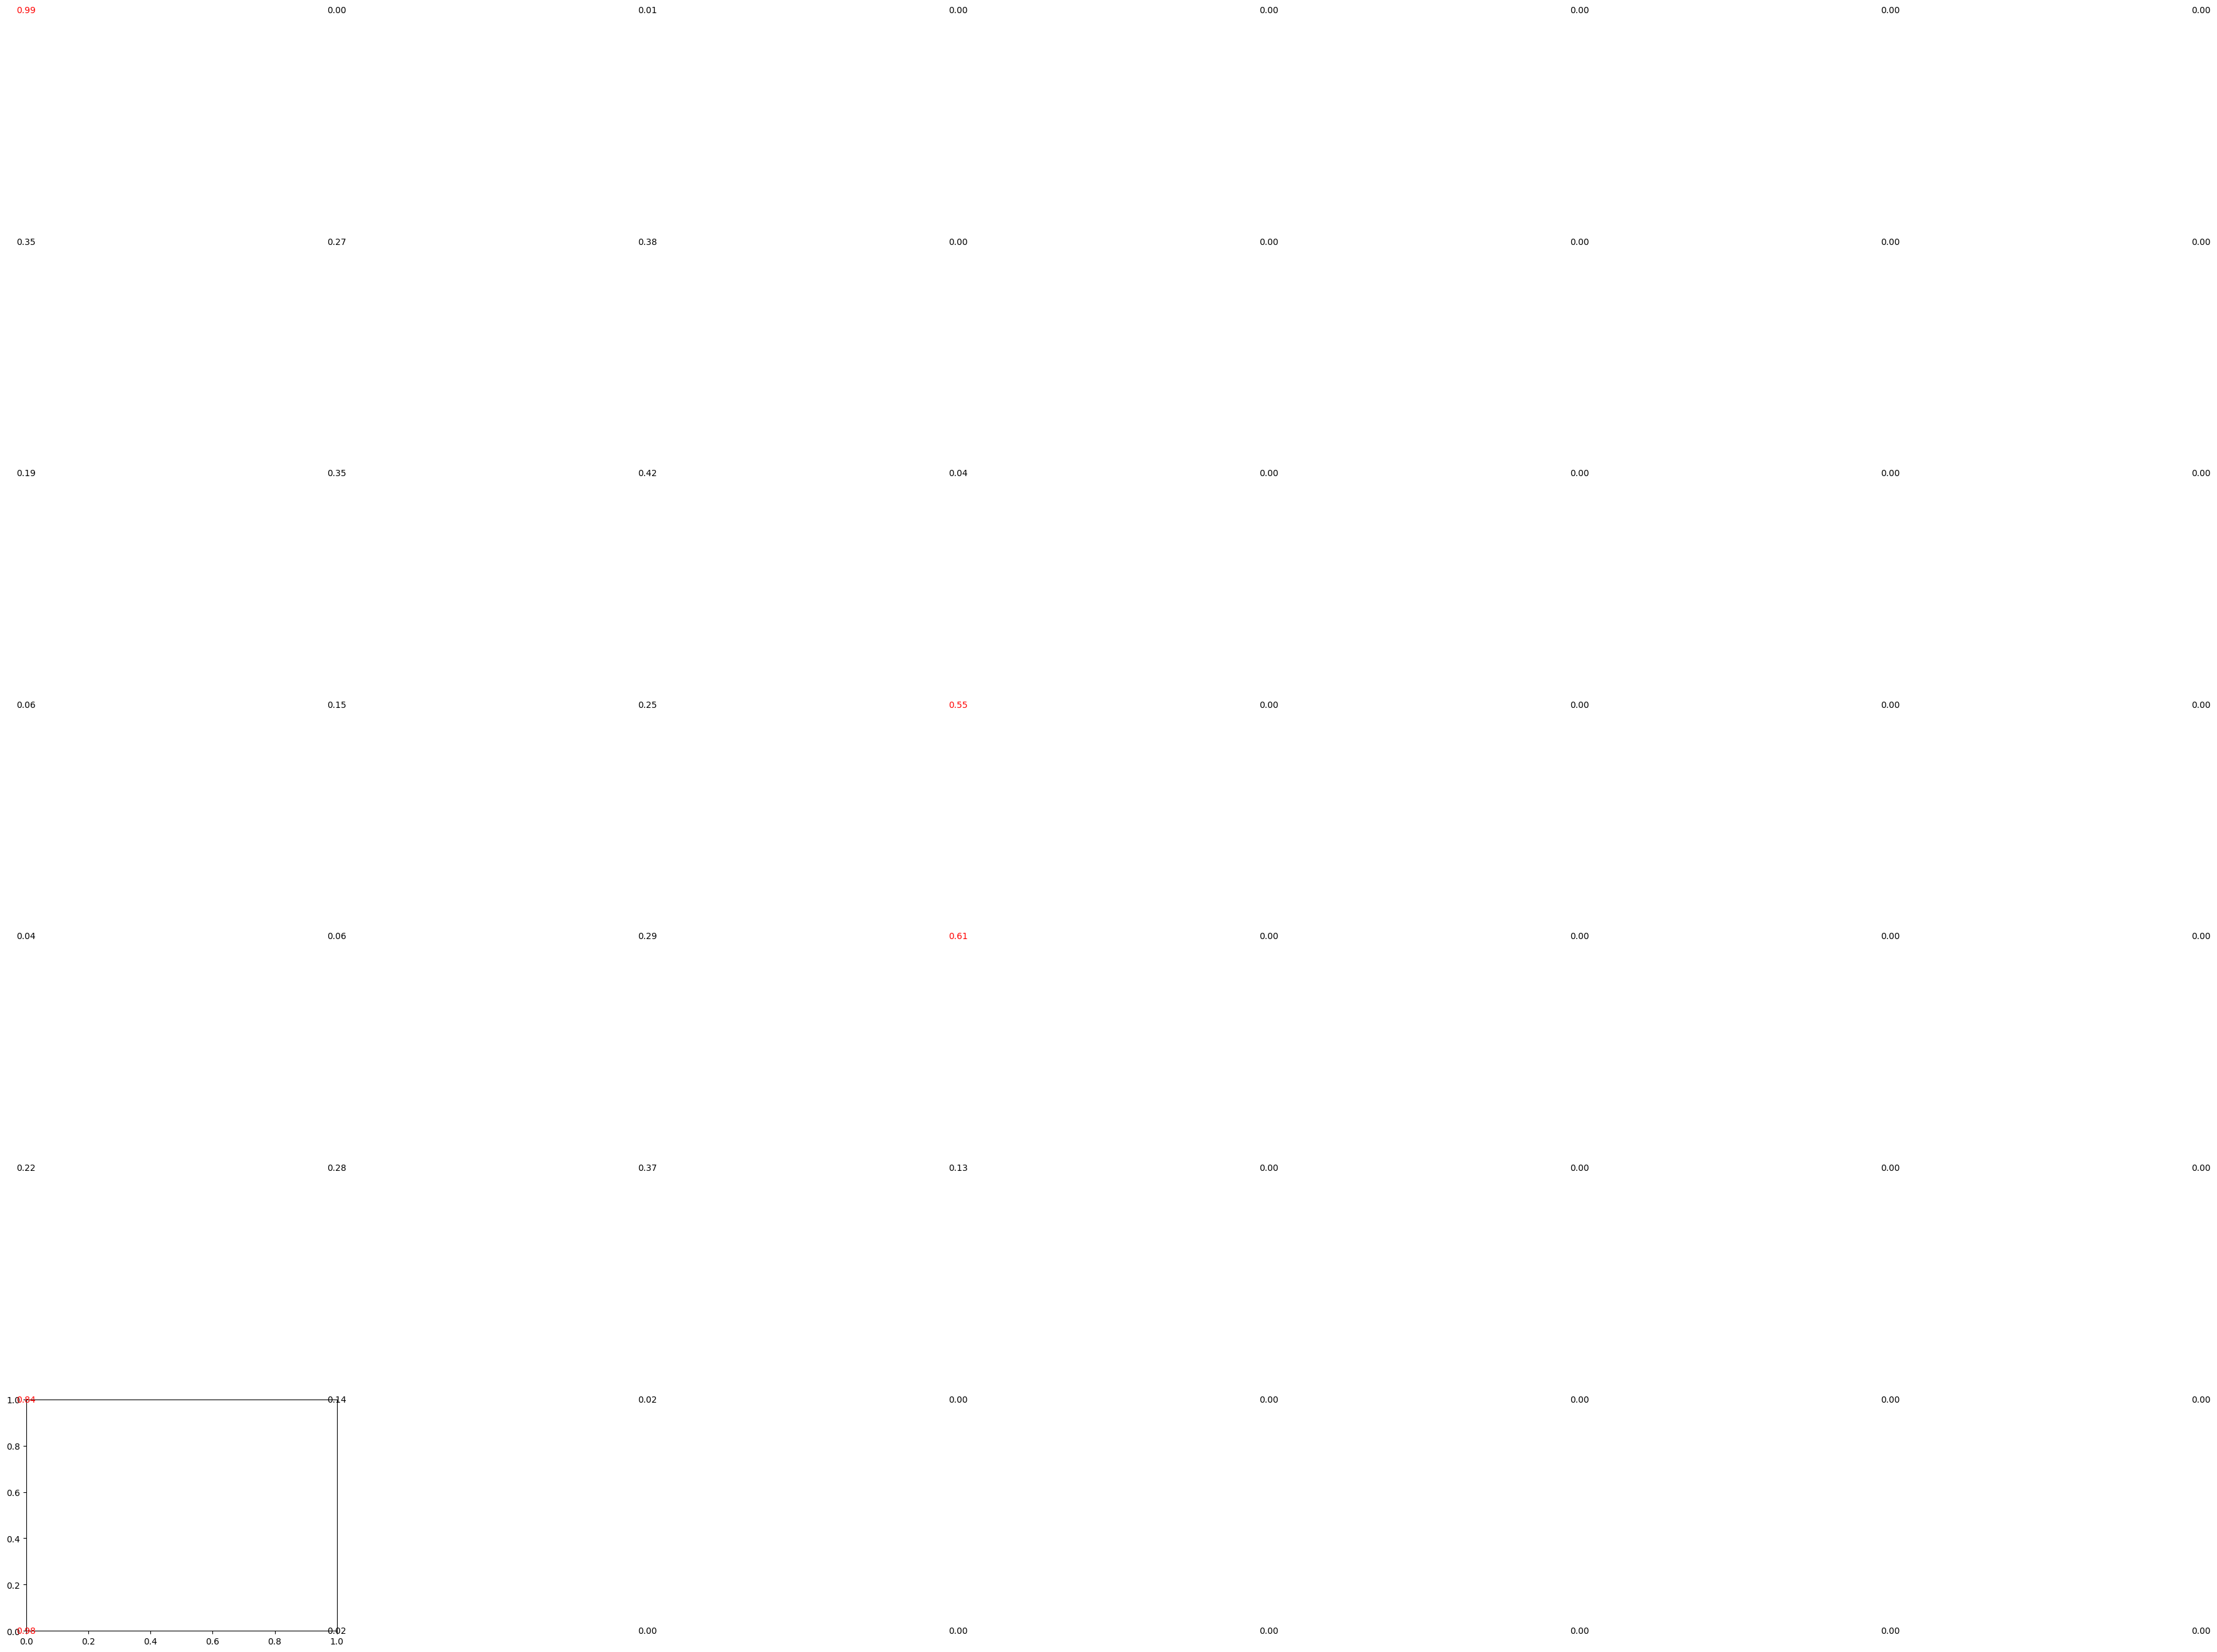

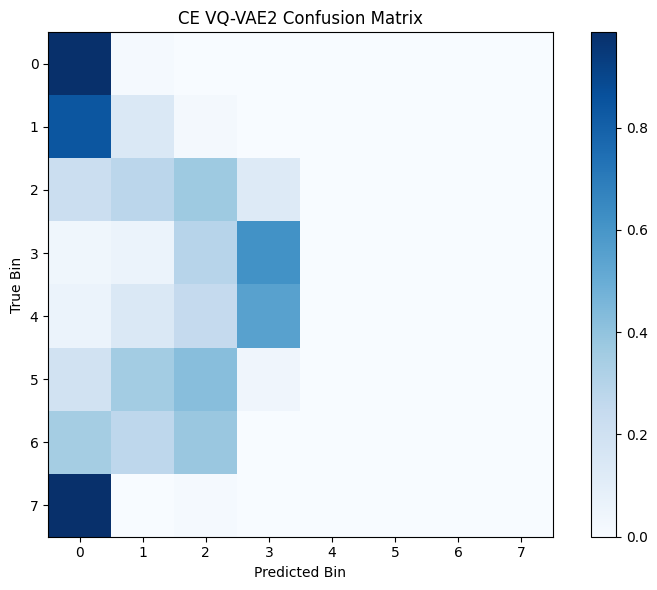

In [ ]:
def generate_confusion_matrix(original, reconstructed, num_bins):
    confusion_matrix = np.zeros((num_bins, num_bins), dtype=int)
    for true_bin in range(num_bins):
        for pred_bin in range(num_bins):
            confusion_matrix[true_bin, pred_bin] = np.sum((original == true_bin) & (reconstructed == pred_bin))
    return confusion_matrix

def plot_confusion_matrix(confusion_matrix, title, row_normalize=True):
    if row_normalize:
        row_sums = confusion_matrix.sum(axis=1, keepdims=True)
        confusion_matrix = confusion_matrix / row_sums
    # Annotate the confusion matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(confusion_matrix.shape[0])
    plt.xticks(tick_marks, range(confusion_matrix.shape[0]))
    plt.yticks(tick_marks, range(confusion_matrix.shape[0]))
    plt.xlabel('Predicted Bin')
    plt.ylabel('True Bin')
    for i in range(confusion_matrix.shape[0]):
        for j in range(confusion_matrix.shape[1]):
            plt.text(j, i, f"{confusion_matrix[i, j]:.2f}", ha='center', va='center', color='red' if confusion_matrix[i, j] > 0.5 else 'black')

    plt.tight_layout()
    plt.show()

focal_confusion_matrix = generate_confusion_matrix(bin_exp, focal_exp_recon, num_bins)
wce_confusion_matrix = generate_confusion_matrix(bin_exp, wce_exp_recon, num_bins)
ce_confusion_matrix = generate_confusion_matrix(bin_exp, ce_exp_recon, num_bins)

plot_confusion_matrix(focal_confusion_matrix, 'Focal VQ-VAE2 Confusion Matrix')
plot_confusion_matrix(wce_confusion_matrix, 'WCE VQ-VAE2 Confusion Matrix')
plot_confusion_matrix(ce_confusion_matrix, 'CE VQ-VAE2 Confusion Matrix')



